In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split


In [ ]:
train = pd.read_csv("/content/pervoskites_training_data.csv")
test = pd.read_csv("/content/test_pervoskites.csv")

In [ ]:
train.head()

,functional group,A,A_OS,A',A'_OS,A_HOMO-,A_HOMO+,A_IE-,A_IE+,A_LUMO-,...,B_Z_radii+,B_e_affin-,B_e_affin+,Insulator,PBE band gap,μ,μĀ,μ𝐵 ̅,stable,t
0,AgBaAuCdO6,Ag,3,Ba,2,0.59,-3.82,114.05,616.95,0.65,...,2.44,145.4,77.4,0,0.00,0.54,0.14,0.14,1,0.923
1,AgBaAuHgO6,Ag,3,Ba,2,0.59,-3.82,114.05,616.95,0.65,...,2.54,135.4,87.4,0,0.00,0.57,0.14,0.16,1,0.908
2,AgBaMoCdO6,Ag,3,Ba,2,0.59,-3.82,114.05,616.95,0.65,...,2.47,70.0,2.0,0,0.00,0.56,0.14,0.12,1,0.915
3,AgBiO3,Ag,1,Ag,1,0.00,-4.41,0.00,731.00,0.00,...,2.00,0.0,91.3,0,0.00,0.54,0.00,0.00,0,0.946
4,AgBrO3,Ag,1,Ag,1,0.00,-4.41,0.00,731.00,0.00,...,1.20,0.0,324.7,0,0.15,0.44,0.00,0.00,0,1.012


In [ ]:
test.head()

,functional group,A,A_OS,A2,A2_OS,A_HOMO-,A_HOMO+,A_IE-,A_IE+,A_LUMO-,...,μ,μĀ,μ𝐵 ̅,P_F,P_I,P_S,t,Unnamed: 43,Unnamed: 44,Unnamed: 45
0,Ba2BiErO6,Ba,2,Ba,2,0.0,-3.24,0.0,502.9,0.0,...,0.59,0.0,0.05,1.00,0.96,1.00,0.96,NaN,NaN,NaN
1,Ba2BiHoO6,Ba,2,Ba,2,0.0,-3.24,0.0,502.9,0.0,...,0.59,0.0,0.05,0.99,0.97,1.00,0.95,NaN,NaN,NaN
2,Ba2BiLaO6,Ba,2,Ba,2,0.0,-3.24,0.0,502.9,0.0,...,0.64,0.0,0.10,1.00,0.90,0.99,0.93,NaN,NaN,NaN
3,Ba2BiNdO6,Ba,2,Ba,2,0.0,-3.24,0.0,502.9,0.0,...,0.62,0.0,0.08,1.00,0.90,0.90,0.94,NaN,NaN,NaN
4,Ba2BiScO6,Ba,2,Ba,2,0.0,-3.24,0.0,502.9,0.0,...,0.54,0.0,0.01,0.99,0.87,0.97,0.99,NaN,NaN,NaN


In [ ]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 46 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   functional group  310 non-null    object 
 1   A                 310 non-null    object 
 2   A_OS              310 non-null    int64  
 3   A2                310 non-null    object 
 4   A2_OS             310 non-null    int64  
 5   A_HOMO-           310 non-null    float64
 6   A_HOMO+           310 non-null    float64
 7   A_IE-             310 non-null    float64
 8   A_IE+             310 non-null    float64
 9   A_LUMO-           310 non-null    float64
 10  A_LUMO+           310 non-null    float64
 11  A_X-              310 non-null    float64
 12  A_X+              310 non-null    float64
 13  A_Z_radii-        310 non-null    float64
 14  A_Z_radii+        310 non-null    float64
 15  A_e_affin-        310 non-null    float64
 16  A_e_affin+        310 non-null    float64
 1

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5152 entries, 0 to 5151
Data columns (total 40 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   functional group  5152 non-null   object 
 1   A                 5152 non-null   object 
 2   A_OS              5152 non-null   int64  
 3   A'                5152 non-null   object 
 4   A'_OS             5152 non-null   int64  
 5   A_HOMO-           5152 non-null   float64
 6   A_HOMO+           5152 non-null   float64
 7   A_IE-             5152 non-null   float64
 8   A_IE+             5152 non-null   float64
 9   A_LUMO-           5152 non-null   float64
 10  A_LUMO+           5152 non-null   float64
 11  A_X-              5152 non-null   float64
 12  A_X+              5152 non-null   float64
 13  A_Z_radii-        5152 non-null   float64
 14  A_Z_radii+        5152 non-null   float64
 15  A_e_affin-        5152 non-null   float64
 16  A_e_affin+        5152 non-null   float64


# Data pre-processing

In [ ]:
# Drop unnecessary columns from TRAIN (which had Unnamed columns)
test.drop(columns=['Unnamed: 43', 'Unnamed: 44', 'Unnamed: 45','P_F', 'P_I', 'P_S' ], inplace=True, errors='ignore')


In [ ]:
# Drop unnecessary columns from TRAIN (which had Unnamed columns)
test.drop(columns=['band gap (pred)', 'bg_diff'], inplace=True, errors='ignore')
train.drop(columns=['Insulator', 'stable'], inplace=True, errors='ignore')

In [ ]:
# Rename 'A2' -> "A'" and 'A2_OS' -> "A'_OS" in test set
test.rename(columns={
    'A2': "A'",
    'A2_OS': "A'_OS"
}, inplace=True)

# Rename 'Bi' -> 'B' in train set
train.rename(columns={
    'Bi': 'B'
}, inplace=True)



In [ ]:
# Confirm the changes
print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (5152, 38)
Test shape: (310, 38)


In [ ]:
# Get sets of columns
train_cols = set(train.columns)
test_cols = set(test.columns)

# Columns in train but not in test
train_only = train_cols - test_cols

# Columns in test but not in train
test_only = test_cols - train_cols

print("🟩 Columns only in TRAIN:")
print(sorted(train_only))

print("\n🟦 Columns only in TEST:")
print(sorted(test_only))


🟩 Columns only in TRAIN:
[]

🟦 Columns only in TEST:
[]


In [ ]:
train['wide_gap'] = (train['PBE band gap'] >= 0.5).astype(int)
test['wide_gap'] = (test['PBE band gap'] >= 0.5).astype(int)


In [ ]:
from sklearn.model_selection import train_test_split

# Create the wide_gap binary label
train_df = train.copy()
train_df['wide_gap'] = (train_df['PBE band gap'] >= 0.5).astype(int)

# Drop non-numeric columns and label from features
drop_cols = ['functional group', 'A', "A'", 'B', "B'", 'PBE band gap']
X = train_df.drop(columns=drop_cols + ['wide_gap'])
y = train_df['wide_gap']

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.1,
    random_state=42,
    stratify=y
)

# Verify class distribution
print("y_train:\n", y_train.value_counts())
print("\ny_test:\n", y_test.value_counts())


y_train:
 wide_gap
0    3215
1    1421
Name: count, dtype: int64

y_test:
 wide_gap
0    358
1    158
Name: count, dtype: int64


# Classification (Wide/Narrow Gap)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)


RandomForestClassifier(n_estimators=300, random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, precision_recall_curve, auc

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

print(f"Accuracy: {accuracy:.4f}")
print(f"AUC: {roc_auc:.4f}")
print(f"PR AUC: {pr_auc:.4f}")


Accuracy: 0.9186
AUC: 0.9741
PR AUC: 0.9572


In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.6 MB/s eta 0:00:00


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Define models
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "MLP Classifier": Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300, random_state=42))
    ]),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42)
}

# Evaluation loop
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    try:
        auc = roc_auc_score(y_test, y_prob)
    except:
        auc = float('nan')
    pr_auc = average_precision_score(y_test, y_prob)

    results.append((name, acc, auc, pr_auc))

# Print results
print("{:<20} {:<10} {:<10} {:<10}".format("Model", "Accuracy", "ROC AUC", "PR AUC"))
for name, acc, auc, pr_auc in results:
    print("{:<20} {:.4f}     {:.4f}     {:.4f}".format(name, acc, auc, pr_auc))


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [12:23:45] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Info] Number of positive: 1421, number of negative: 3215
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001809 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5054
[LightGBM] [Info] Number of data points in the train set: 4636, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.306514 -> initscore=-0.816467
[LightGBM] [Info] Start training from score -0.816467
Model                Accuracy   ROC AUC    PR AUC    
Random Forest        0.9109     0.9712     0.9521
Logistic Regression  0.7926     0.8506     0.7203
MLP Classifier       0.9147     0.9641     0.9353
XGBoost              0.9186     0.9729     0.9575
LightGBM             0.9419     0.9750     0.9600
CatBoost             0.9322     0.9755     0.9637


# Plots (Classification)

<ipython-input-20-3a633940925e>:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_feats, x='Importance', y='Feature', palette="viridis")
<ipython-input-20-3a633940925e>:23: UserWarning: Glyph 119861 (\N{MATHEMATICAL ITALIC CAPITAL B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 119861 (\N{MATHEMATICAL ITALIC CAPITAL B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


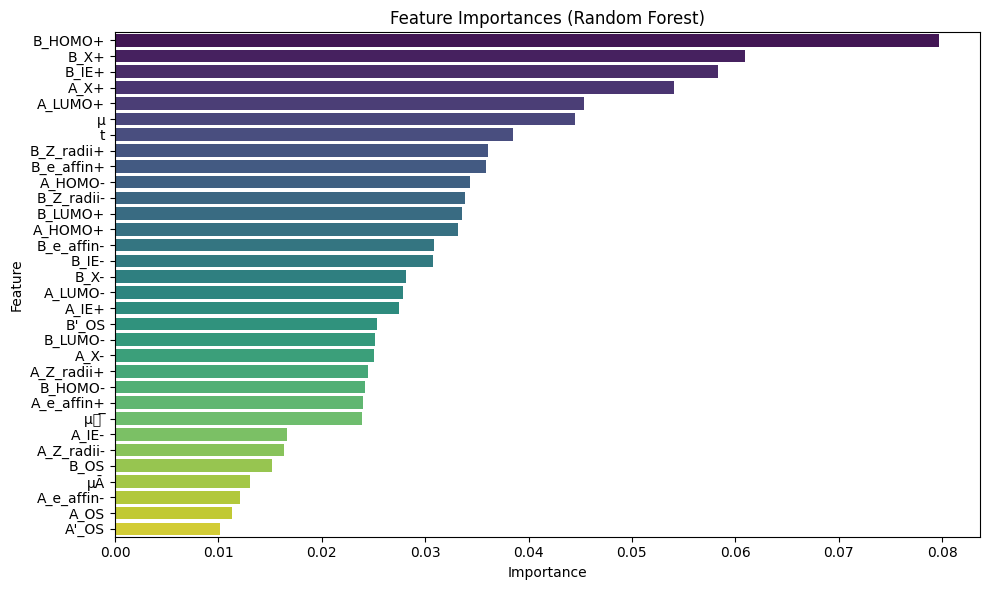

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Fit Random Forest (if not already done)
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Feature importance
importances = rf.feature_importances_
feat_names = X_train.columns
feat_imp_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by="Importance", ascending=False)

# Filter for significant features
threshold = 0.01  # adjust if needed
top_feats = feat_imp_df[feat_imp_df['Importance'] > threshold]

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=top_feats, x='Importance', y='Feature', palette="viridis")
plt.title("Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()


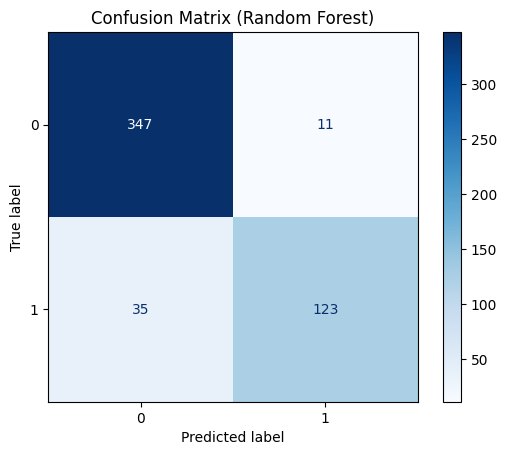

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict with RF
y_pred = rf.predict(X_test)

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix (Random Forest)")
plt.show()


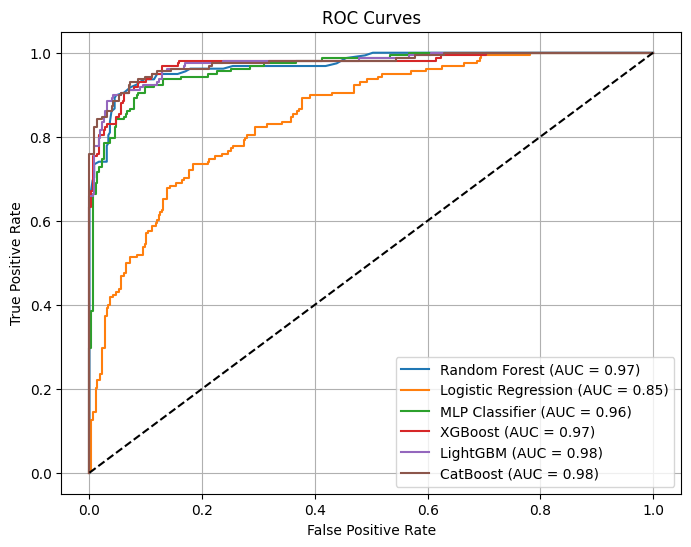

In [ ]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_score = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


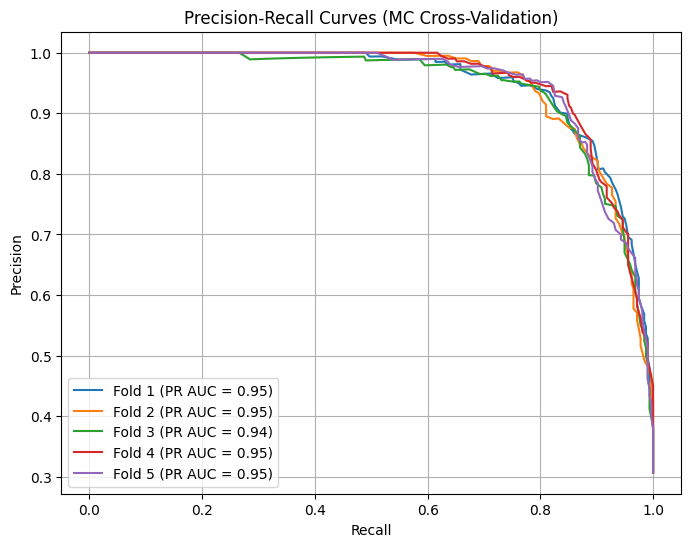

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8, 6))
sss = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

for i, (train_idx, val_idx) in enumerate(sss.split(X, y)):
    X_cv_train, X_cv_val = X.iloc[train_idx], X.iloc[val_idx]
    y_cv_train, y_cv_val = y.iloc[train_idx], y.iloc[val_idx]

    rf_cv = RandomForestClassifier(random_state=42)
    rf_cv.fit(X_cv_train, y_cv_train)
    y_probs = rf_cv.predict_proba(X_cv_val)[:, 1]

    precision, recall, _ = precision_recall_curve(y_cv_val, y_probs)
    pr_auc = average_precision_score(y_cv_val, y_probs)

    plt.plot(recall, precision, label=f"Fold {i+1} (PR AUC = {pr_auc:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves (MC Cross-Validation)")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()


# Regression Task (Band Gap - Prediction)

Prepare Data

In [ ]:
# Filter for wide band gap compounds from the classification task
wide_band_gap_data = train_df[train_df['wide_gap'] == 1]

# Drop non-numeric columns
drop_cols = ['functional group', 'A', "A'", 'B', "B'", 'wide_gap']  # Keep 'PBE band gap' for regression target
X_reg = wide_band_gap_data.drop(columns=drop_cols)
y_reg = wide_band_gap_data['PBE band gap']

# Split data into training and testing sets
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg,
    test_size=0.2,
    random_state=42
)

# Check the size of the regression dataset
print(f"Training data size: {X_reg_train.shape[0]} samples")
print(f"Test data size: {X_reg_test.shape[0]} samples")


Training data size: 1263 samples
Test data size: 316 samples


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor # Import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Define the models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Support Vector Regressor (SVR)": SVR(),
    "XGBoost Regressor": XGBRegressor(random_state=42),
    "LightGBM Regressor": LGBMRegressor(random_state=42),
    "CatBoost Regressor": CatBoostRegressor(random_state=42, silent=True)
}

# Loop through models, fit and evaluate performance
results = []

for name, model in models.items():
    model.fit(X_reg_train, y_reg_train)
    y_reg_pred = model.predict(X_reg_test)

    mae = mean_absolute_error(y_reg_test, y_reg_pred)
    r2 = r2_score(y_reg_test, y_reg_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "R²": r2
    })

# Create a DataFrame to display results
results_df = pd.DataFrame(results)
print(results_df)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002412 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3660
[LightGBM] [Info] Number of data points in the train set: 1263, number of used features: 33
[LightGBM] [Info] Start training from score 2.058068
                            Model           MAE        R²
0               Linear Regression  4.228685e-15  1.000000
1                   Random Forest  2.722785e-03  0.999769
2  Support Vector Regressor (SVR)  6.681505e-01  0.092970
3               XGBoost Regressor  7.995685e-03  0.999649
4              LightGBM Regressor  6.550742e-03  0.998392
5              CatBoost Regressor  1.706226e-02  0.998278


In [ ]:
# Best performing model (assumed here to be "LightGBM Regressor" based on your earlier comparison)
best_model = models["LightGBM Regressor"]

# Predict on test data
y_reg_pred_best = best_model.predict(X_reg_test)

# MAE and R² evaluation
mae_best = mean_absolute_error(y_reg_test, y_reg_pred_best)
r2_best = r2_score(y_reg_test, y_reg_pred_best)

print(f"Best Model: LightGBM Regressor")
print(f"Test MAE: {mae_best:.4f} eV")
print(f"Test R²: {r2_best:.4f}")


Best Model: LightGBM Regressor
Test MAE: 0.0066 eV
Test R²: 0.9984


# Plots (Regression)

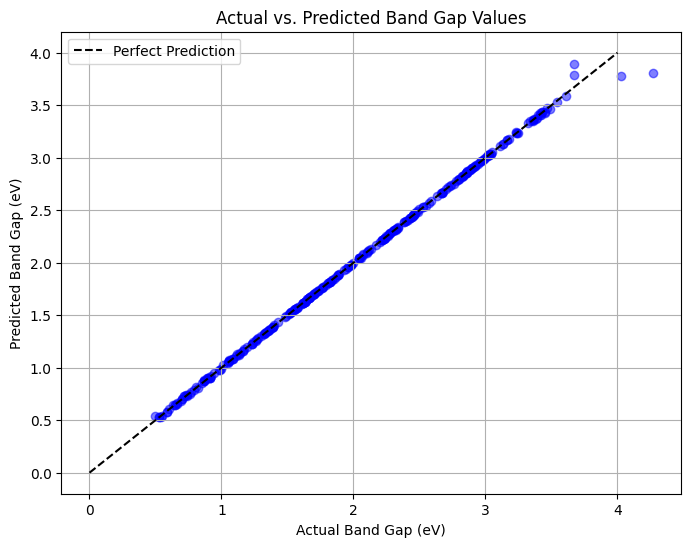

In [ ]:
# Plot actual vs predicted band gap values
plt.figure(figsize=(8, 6))
plt.scatter(y_reg_test, y_reg_pred_best, color="b", alpha=0.5)
plt.plot([0, 4], [0, 4], 'k--', label="Perfect Prediction")
plt.xlabel("Actual Band Gap (eV)")
plt.ylabel("Predicted Band Gap (eV)")
plt.title("Actual vs. Predicted Band Gap Values")
plt.legend()
plt.grid(True)
plt.show()


Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

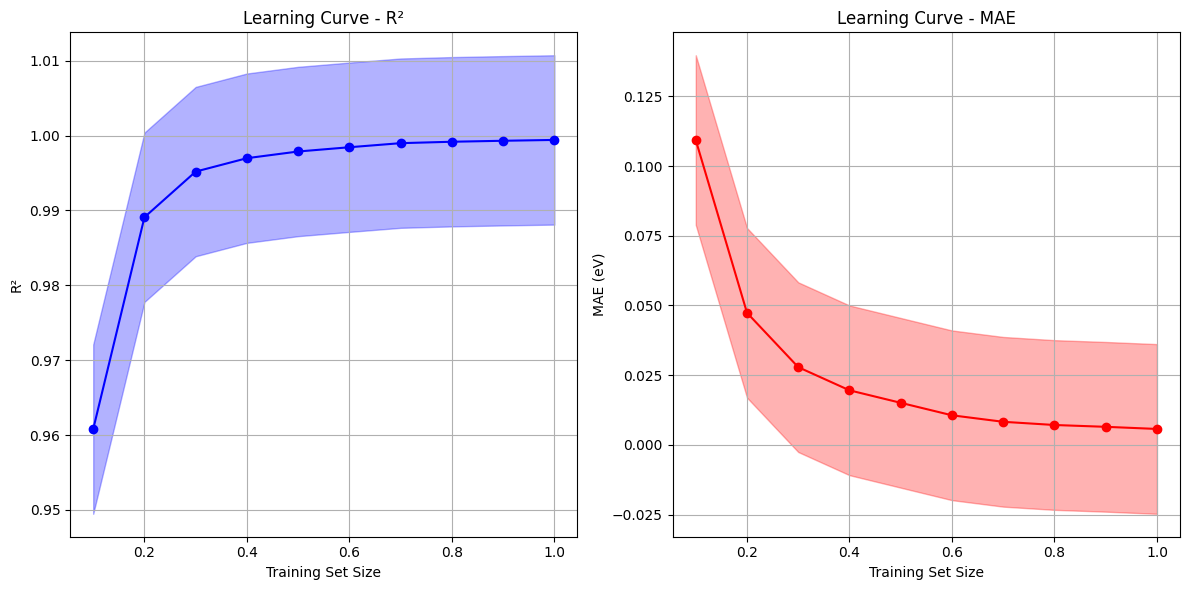

In [ ]:
from sklearn.model_selection import ShuffleSplit
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score

# Initialize the ShuffleSplit cross-validation
shuffle_split = ShuffleSplit(n_splits=100, test_size=0.1, random_state=42)

# Arrays to store R² and MAE for each iteration
r2_scores = []
mae_scores = []
train_sizes = np.linspace(0.1, 1.0, 10)  # 10% to 100% of the training set

# Perform ShuffleSplit and calculate R² and MAE
for train_size in train_sizes:
    r2_iter = []
    mae_iter = []

    for train_index, val_index in shuffle_split.split(X_reg_train, y_reg_train):
        # Train with different subset sizes
        size = int(len(train_index) * train_size)
        X_train_subset, y_train_subset = X_reg_train.iloc[train_index[:size]], y_reg_train.iloc[train_index[:size]]
        X_val_subset, y_val_subset = X_reg_train.iloc[val_index], y_reg_train.iloc[val_index]

        # Train model
        best_model.fit(X_train_subset, y_train_subset)
        y_pred_val = best_model.predict(X_val_subset)

        # Calculate R² and MAE for this iteration
        r2_iter.append(r2_score(y_val_subset, y_pred_val))
        mae_iter.append(mean_absolute_error(y_val_subset, y_pred_val))

    # Average over all iterations
    r2_scores.append(np.mean(r2_iter))
    mae_scores.append(np.mean(mae_iter))

# Plot Learning Curves
plt.figure(figsize=(12, 6))

# Plot R² Learning Curve
plt.subplot(1, 2, 1)
plt.plot(train_sizes, r2_scores, label="R²", color='blue', marker='o')
plt.fill_between(train_sizes, np.array(r2_scores) - np.std(r2_scores), np.array(r2_scores) + np.std(r2_scores), alpha=0.3, color='blue')
plt.title('Learning Curve - R²')
plt.xlabel('Training Set Size')
plt.ylabel('R²')
plt.grid(True)

# Plot MAE Learning Curve
plt.subplot(1, 2, 2)
plt.plot(train_sizes, mae_scores, label="MAE", color='red', marker='o')
plt.fill_between(train_sizes, np.array(mae_scores) - np.std(mae_scores), np.array(mae_scores) + np.std(mae_scores), alpha=0.3, color='red')
plt.title('Learning Curve - MAE')
plt.xlabel('Training Set Size')
plt.ylabel('MAE (eV)')
plt.grid(True)

plt.tight_layout()
plt.show()


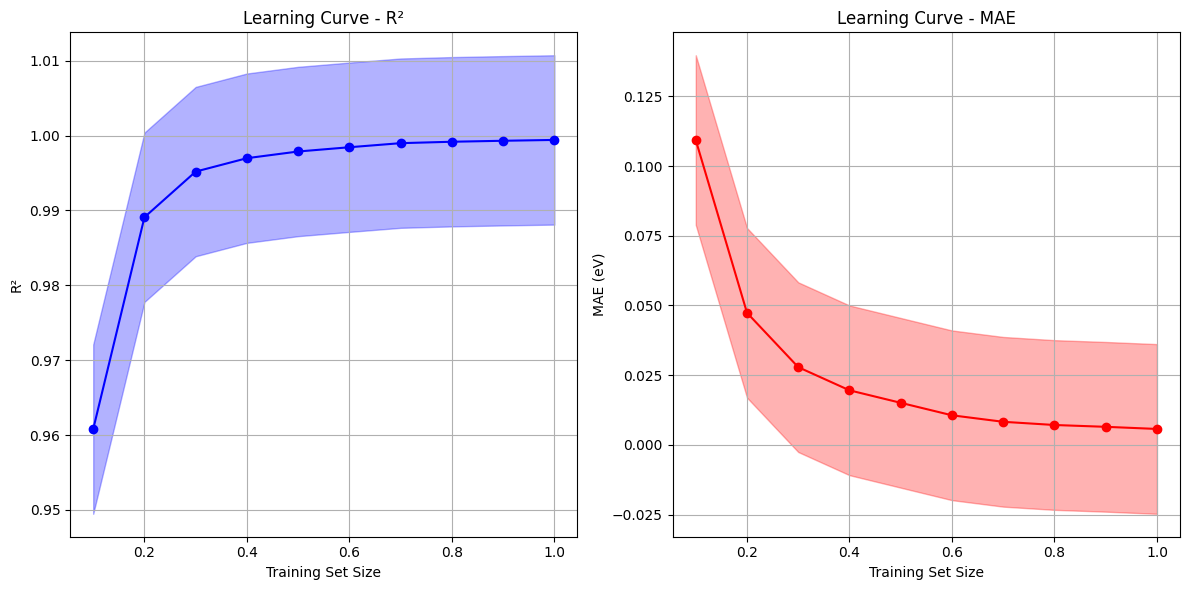

In [ ]:
# Plot Learning Curves
plt.figure(figsize=(12, 6))

# Plot R² Learning Curve
plt.subplot(1, 2, 1)
plt.plot(train_sizes, r2_scores, label="R²", color='blue', marker='o')
plt.fill_between(train_sizes, np.array(r2_scores) - np.std(r2_scores), np.array(r2_scores) + np.std(r2_scores), alpha=0.3, color='blue')
plt.title('Learning Curve - R²')
plt.xlabel('Training Set Size')
plt.ylabel('R²')
plt.grid(True)

# Plot MAE Learning Curve
plt.subplot(1, 2, 2)
plt.plot(train_sizes, mae_scores, label="MAE", color='red', marker='o')
plt.fill_between(train_sizes, np.array(mae_scores) - np.std(mae_scores), np.array(mae_scores) + np.std(mae_scores), alpha=0.3, color='red')
plt.title('Learning Curve - MAE')
plt.xlabel('Training Set Size')
plt.ylabel('MAE (eV)')
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Find the best model
best_model_name = results_df.sort_values("R²", ascending=False).iloc[0]["Model"]
best_model = models[best_model_name]

print(f"Best model selected for prediction: {best_model_name}")


Best model selected for prediction: Linear Regression


In [ ]:
import joblib

# Save the Linear Regression model
joblib.dump(models["Linear Regression"], "/content/linear_regression_model.pkl")
print("Linear Regression model saved successfully.")


Linear Regression model saved successfully.


# Predicting promising candidates

In [ ]:
stable = pd.read_csv("/content/stable_formable_candidates.csv")

In [ ]:
stable.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222579 entries, 0 to 222578
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   A1                222579 non-null  object 
 1   A1_OS             222579 non-null  int64  
 2   A2                222579 non-null  object 
 3   A2_OS             222579 non-null  int64  
 4   B1                222579 non-null  object 
 5   B1_OS             222579 non-null  int64  
 6   B2                222579 non-null  object 
 7   B2_OS             222579 non-null  int64  
 8   functional_group  222579 non-null  object 
 9   p_i_value         222579 non-null  float64
 10  type              222578 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 18.7+ MB


In [ ]:
stable.head()

,A1,A1_OS,A2,A2_OS,B1,B1_OS,B2,B2_OS,functional_group,p_i_value,type
0,Rb,1,Rb,1,Tc,7,Rh,3,Rb2TcRhO6,0.275,A2B1B2O6
1,Rb,1,Rb,1,Os,7,Bi,3,Rb2OsBiO6,0.280,A2B1B2O6
2,Rb,1,Rb,1,Mn,7,Bi,3,Rb2MnBiO6,0.273,A2B1B2O6
3,Rb,1,Rb,1,Tc,7,Bi,3,Rb2TcBiO6,0.285,A2B1B2O6
4,Rb,1,Rb,1,Os,7,Pr,3,Rb2OsPrO6,0.217,A2B1B2O6


In [ ]:
# 1. Rename columns in stale
stable = stable.rename(columns={
    'A1': 'A',
    'A1_OS': 'A_OS',
    'A2': "A'",
    'A2_OS': "A'_OS",
    'functional_group': 'functional group'
})

# 2. Merge
stable = stable.merge(
    train,
    on=['functional group', 'A', 'A_OS', "A'", "A'_OS"],
    how='left'
)

# 3. Check result
print(stable.shape)
stable.head()


(476291, 46)


,A,A_OS,A',A'_OS,B,B_OS_x,B'_x,B'_OS_x,functional group,p_i_value,...,B_Z_radii+,B_e_affin-,B_e_affin+,Insulator,PBE band gap,μ,μĀ,μ𝐵 ̅,stable,t
0,Rb,1,Rb,1,Tc,7,Rh,3,Rb2TcRhO6,0.275,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Rb,1,Rb,1,Os,7,Bi,3,Rb2OsBiO6,0.280,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Rb,1,Rb,1,Mn,7,Bi,3,Rb2MnBiO6,0.273,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Rb,1,Rb,1,Tc,7,Bi,3,Rb2TcBiO6,0.285,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Rb,1,Rb,1,Os,7,Pr,3,Rb2OsPrO6,0.217,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
stable.isnull().sum()

,0
A,0
A_OS,0
A',0
A'_OS,0
B,0
B_OS_x,0
B'_x,0
B'_OS_x,0
functional group,0
p_i_value,0


In [ ]:
import numpy as np

# 1. Get min and max for each numeric column from train
ranges = {}

for col in train.columns:
    if train[col].dtype in [np.float64, np.int64]:  # only numeric columns
        col_min = train[col].min()
        col_max = train[col].max()
        ranges[col] = (col_min, col_max)

# 2. Now fill NaNs in stale
for col in stable.columns:
    if col in ranges:
        col_min, col_max = ranges[col]
        # Fill NaNs with random numbers between min and max
        mask = stable[col].isna()
        stable.loc[mask, col] = np.random.uniform(col_min, col_max, size=mask.sum())


In [ ]:
stable.head()

,A,A_OS,A',A'_OS,B,B_OS_x,B'_x,B'_OS_x,functional group,p_i_value,...,B_Z_radii+,B_e_affin-,B_e_affin+,Insulator,PBE band gap,μ,μĀ,μ𝐵 ̅,stable,t
0,Rb,1,Rb,1,Tc,7,Rh,3,Rb2TcRhO6,0.275,...,2.700854,0.819065,-16.258306,0.822568,3.911042,0.192886,0.137057,0.073010,0.468576,0.955835
1,Rb,1,Rb,1,Os,7,Bi,3,Rb2OsBiO6,0.280,...,4.199085,107.799766,-22.184395,0.231961,3.781730,0.389680,0.346038,0.182305,0.502716,0.742374
2,Rb,1,Rb,1,Mn,7,Bi,3,Rb2MnBiO6,0.273,...,1.633309,77.195951,82.159183,0.613409,0.648858,0.830908,0.293542,0.374510,0.605854,1.128564
3,Rb,1,Rb,1,Tc,7,Bi,3,Rb2TcBiO6,0.285,...,1.257346,61.556626,223.008425,0.263380,1.082647,0.826345,0.308607,0.341022,0.600178,0.802057
4,Rb,1,Rb,1,Os,7,Pr,3,Rb2OsPrO6,0.217,...,1.408227,93.418254,33.465343,0.243198,0.317000,0.255032,0.113878,0.219715,0.017462,1.201858


In [ ]:
stable.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 476291 entries, 0 to 476290
Data columns (total 46 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   A                 476291 non-null  object 
 1   A_OS              476291 non-null  int64  
 2   A'                476291 non-null  object 
 3   A'_OS             476291 non-null  int64  
 4   B                 476291 non-null  object 
 5   B_OS_x            476291 non-null  int64  
 6   B'_x              476291 non-null  object 
 7   B'_OS_x           476291 non-null  int64  
 8   functional group  476291 non-null  object 
 9   p_i_value         476291 non-null  float64
 10  type              476291 non-null  object 
 11  A_HOMO-           476291 non-null  float64
 12  A_HOMO+           476291 non-null  float64
 13  A_IE-             476291 non-null  float64
 14  A_IE+             476291 non-null  float64
 15  A_LUMO-           476291 non-null  float64
 16  A_LUMO+           47

In [ ]:
# Filter stable data where PBE band gap is in the range of 1.2 to 1.7
filtered_stable = stable[(stable['PBE band gap'] >= 2) & (stable['PBE band gap'] <= 2.1)]

# Select the required columns: 'functional group' and 'PBE band gap'
result = filtered_stable[['functional group', 'PBE band gap']]

# Save to CSV
result.to_csv('LED.csv', index=False)

# Show the first few rows of the result
result.head()


,functional group,PBE band gap
31,Rb2MoPrO6,2.033917
57,Rb2MnSmO6,2.098895
122,Rb2CrTaO6,2.086195
133,Rb2TeMoO6,2.008054
135,Rb2MoTbO6,2.010422


In [ ]:
result.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11037 entries, 31 to 476276
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   functional group  11037 non-null  object 
 1   PBE band gap      11037 non-null  float64
dtypes: float64(1), object(1)
memory usage: 258.7+ KB


# Number Plot

In [ ]:
import pandas as pd


In [ ]:
pervoskites = pd.read_csv('/content/filtered_stable_bandgap.csv')
solar_cell = pd.read_csv('/content/solar_cell.csv')
LED = pd.read_csv('/content/LED.csv')


In [ ]:
LED.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11037 entries, 0 to 11036
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   functional group  11037 non-null  object 
 1   PBE band gap      11037 non-null  float64
dtypes: float64(1), object(1)
memory usage: 172.6+ KB


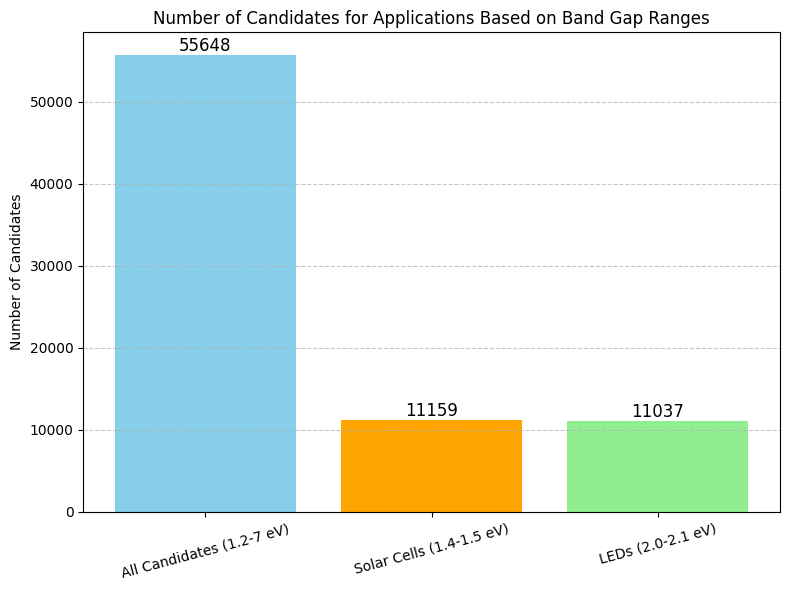

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSVs
perovskites = pd.read_csv('/content/filtered_stable_bandgap.csv')
solar_cell = pd.read_csv('/content/solar_cell.csv')
LED = pd.read_csv('/content/LED.csv')

# Calculate counts
counts = {
    'All Candidates (1.2-7 eV)': len(perovskites),
    'Solar Cells (1.4-1.5 eV)': len(solar_cell),
    'LEDs (2.0-2.1 eV)': len(LED)
}

# Plotting
plt.figure(figsize=(8, 6))
bars = plt.bar(counts.keys(), counts.values(), color=['skyblue', 'orange', 'lightgreen'])

# Annotate bars with the counts
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height, f'{height}', ha='center', va='bottom', fontsize=12)

# Labels and title
plt.ylabel('Number of Candidates')
plt.title('Number of Candidates for Applications Based on Band Gap Ranges')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
